# HealthConnect Clinic - No-Show Prediction
## Data Science Track - Week 5: Data Preparation, Feature Engineering & Baseline Model Development

**Project:** AnalystLab Africa Experience Lab

**Author:** Ange Maxime TCHOUTANG

**Week:** 5 - Data Preparation, Feature Engineering, Train/Test Strategy, Baseline Model, Initial Evaluation

**Dataset:** `HealthConnect_Appointment_Data.csv`

**Builds on:** `HealthConnect_NoShow_Problem_Definition.ipynb` (Week 4)

---

### Contents
1. [Week 4 Foundation Review](#1)
2. [Data Preparation](#2)
3. [Data Exploration & Visual Evidence](#3)
4. [Feature Engineering](#4)
5. [Train / Test Strategy](#5)
6. [Baseline Model](#6)
7. [Initial Evaluation](#7)
8. [Interpretation](#8)
9. [Modelling Limitations](#9)
10. [Assumptions, Limitations, Risks & Dependencies — Update](#10)
11. [Cross-Track Collaboration](#11)
12. [Recommendations for Week 6](#12)


<a id="1"></a>
## 1. Week 4 Foundation Review

A brief transition — full reasoning is in the Week 4 notebook (`HealthConnect_NoShow_Problem_Definition.ipynb`); this section confirms what carries forward rather than repeating it.

**Problem defined.** Supervised binary classification at the appointment level: using only information known before the appointment happens, predict whether a scheduled appointment will be **Attended** or end in a **No-Show**.

**Proposed target.** `target = 1` if `appointment_outcome == 'No-Show'`, `target = 0` if `appointment_outcome == 'Attended'`. **Cancelled appointments excluded** from the primary model (proactive patient action, operationally distinct from a silent no-show).

**Candidate features (Week 4).** `gender`, `age`, `appointment_type`, `appointment_time`, `appointment_day`, `booking_lead_days`, `previous_appointments`, `previous_no_shows`, `historical_no_show_rate` (engineered), `distance_to_clinic_km`, `reminder_sent`, `reminder_channel`. `waiting_time_minutes` was **excluded as a leakage risk** (populated even for appointments never attended - its pre/post-visit timing is ambiguous).

**HealthConnect resources used.** `HealthConnect_Appointment_Data.csv` (5,000 rows) and `HealthConnect_Data_Dictionary.xlsx`; `HealthConnect_Clinic_Knowledge_Base.docx` was used in Week 4 to cross-check business rules (e.g. the Sunday-closure policy) and is not re-used for modelling directly.

**Key assumptions / limitations carried forward.**

- Data is synthetic/fictional - relationships found here should be re-validated on real data before production use.
- 1,696 unique patients generate 5,000 rows → rows are **not independent**; splits must be patient-grouped.
- Two open data-quality questions: 737 appointments fall on a Sunday despite a stated Sunday-closure policy; `waiting_time_minutes` has ambiguous timing.

**Proposed Week 5 focus (from Week 4).** Resolve the flagged data-quality questions where possible, build the preprocessing pipeline, implement the patient-grouped split, train Logistic Regression and a tree-based ensemble baseline, and evaluate on recall/precision for the No-Show class plus ROC-AUC.

**Where Week 5 confirms vs. changes the Week 4 plan:** the target definition, cancellation handling and feature exclusion for `waiting_time_minutes` are all **confirmed** below using the full dataset rather than the exploratory sample used in Week 4. One refinement is introduced: `appointment_id` and `patient_id` are formally documented as identifiers rather than features (implicit in Week 4, made explicit here), and `booking_date`/`appointment_date` are dropped as raw model inputs in favour of the already-derived `booking_lead_days` and `appointment_day`, to avoid the model latching onto absolute calendar dates that will not repeat in future data.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                              RocCurveDisplay, classification_report)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## Data Loading

In [4]:
raw = pd.read_csv('C:/Users/Ange/Downloads/Training Data S. africa Lab/week 5/Data/HealthConnect_Appointment_Data.csv')
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 5,000   Columns: 18


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


<a id="2"></a>
## 2. Data Preparation

We work on a copy of the dataset throughout - **the original `HealthConnect_Appointment_Data.csv` is never modified or overwritten**; all cleaned/derived data stays in this notebook's `df` (and, further down, `model_df`) in memory only.


In [5]:
df = raw.copy()  # never modify `raw` — keeps the original dataset intact for reference

df.dtypes

appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

### 2.1 Data types

Data types are appropriate for every column except the two date columns, which pandas reads as generic strings (`object`). We parse them explicitly to `datetime64` so they can be used safely for the consistency checks and any date-derived features.


In [6]:
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')
df[['booking_date','appointment_date']].dtypes

booking_date        datetime64[ns]
appointment_date    datetime64[ns]
dtype: object

### 2.2 Missing values


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


Confirmed from Week 4: three columns carry missing values.

- **`reminder_channel`** - missing exactly when `reminder_sent == 'No'` (structural, not random). **Decision:** encode explicitly as the category `"None"` rather than imputing a channel that was never used.
  
- **`distance_to_clinic_km`** (1.8%) and **`waiting_time_minutes`** (1.2%) - small, unstructured missingness. **Decision:** median imputation for `distance_to_clinic_km` inside the modelling pipeline (fit on the training fold only, see §5); `waiting_time_minutes` is dropped entirely as a feature (§2.6), so its missingness is moot for modelling.


In [8]:
df['reminder_channel'] = df['reminder_channel'].fillna('None')
assert df['reminder_channel'].isnull().sum() == 0
df['reminder_channel'].value_counts()

reminder_channel
SMS         2000
None        1366
WhatsApp    1101
Email        533
Name: count, dtype: int64

### 2.3 Duplicates


In [9]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate appointment_id values:", df['appointment_id'].duplicated().sum())

Fully duplicated rows: 0
Duplicate appointment_id values: 0


No duplicate rows and no duplicate `appointment_id` values - each row is a distinct appointment, confirmed again on the full dataset. No de-duplication action is required.


### 2.4 Inconsistent records

Re-running the Week 4 consistency checks on the full dataset, plus one additional check on categorical value sets:


In [10]:
calc_lead = (df['appointment_date'] - df['booking_date']).dt.days
calc_weekday = df['appointment_date'].dt.day_name()

checks = {
    'booking_lead_days mismatches vs recalculated': (calc_lead != df['booking_lead_days']).sum(),
    'Negative lead time (booked after appointment)': (calc_lead < 0).sum(),
    'appointment_day mismatches vs recalculated weekday': (calc_weekday != df['appointment_day']).sum(),
    'previous_no_shows > previous_appointments': (df['previous_no_shows'] > df['previous_appointments']).sum(),
    'Negative numeric values (distance/waiting/age/lead)':
        (df[['distance_to_clinic_km','waiting_time_minutes','age','booking_lead_days']] < 0).any(axis=1).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v}")

print()
print("Categorical value sets:")
for c in ['gender','appointment_type','appointment_time','reminder_sent','appointment_outcome']:
    print(f"  {c}: {sorted(df[c].unique())}")

booking_lead_days mismatches vs recalculated: 0
Negative lead time (booked after appointment): 0
appointment_day mismatches vs recalculated weekday: 0
previous_no_shows > previous_appointments: 0
Negative numeric values (distance/waiting/age/lead): 0

Categorical value sets:
  gender: ['Female', 'Male', 'Prefer not to say']
  appointment_type: ['Diagnostic Test', 'Follow-up', 'General Consultation', 'Specialist Consultation']
  appointment_time: ['Afternoon', 'Evening', 'Morning']
  reminder_sent: ['No', 'Yes']
  appointment_outcome: ['Attended', 'Cancelled', 'No-Show']


Every engineered/derived field remains internally consistent, no impossible negative values exist, and every categorical column contains only the values documented in the Data Dictionary (no stray free-text or typos to clean). **One genuine inconsistency remains flagged, not silently fixed:**


In [11]:
sunday_appts = (calc_weekday == 'Sunday').sum()
print(f"Appointments scheduled on a Sunday: {sunday_appts} ({sunday_appts/len(df):.1%})")

Appointments scheduled on a Sunday: 737 (14.7%)


**Decision on the Sunday anomaly.** The Clinic Knowledge Base states the clinic is closed on Sundays, yet 14.7% of appointments fall on a Sunday. Because this cannot be resolved analytically (it requires a business-owner decision on whether these rows are a data-generation artefact or the policy documentation is out of date), we **retain these rows for modelling** rather than dropping ~15% of the data on an unconfirmed assumption, but we flag `appointment_day` results involving Sunday as **lower-confidence** and revisit this if a stakeholder clarifies the policy in Week 6.

### 2.5 Categorical variables

Nominal categorical columns for modelling: `gender`, `appointment_type`, `appointment_time`, `appointment_day`, `reminder_sent`, `reminder_channel`. None are ordinal in a way that benefits from manual ordering, so all will be **one-hot encoded** inside the modelling pipeline (§5-6) rather than label-encoded, to avoid implying a false order to a linear model like Logistic Regression.

### 2.6 Irrelevant variables and potential leakage

| Column | Decision | Reason |
|---|---|---|
| `appointment_id` | **Drop** | Pure row identifier, no predictive meaning, would not generalise. |
| `patient_id` | **Drop as a feature**, keep for grouping | Too high-cardinality to one-hot encode (1,696 levels) - the model would effectively memorise individual patients rather than learn generalisable behaviour. Retained separately to (a) group the train/test split (§5) and (b) build the `historical_no_show_rate` feature (§4). |
| `booking_date`, `appointment_date` | **Drop as raw features** | Absolute calendar dates will not repeat in future data and risk the model learning spurious date-specific patterns; their useful signal is already captured by `booking_lead_days` and `appointment_day`. |
| `waiting_time_minutes` | **Drop - leakage risk** | Data dictionary calls it an "estimated waiting time," but it is populated even for No-Show and Cancelled appointments and shows no relationship with the outcome (~24 min average in every outcome group, confirmed again below). If it is in fact recorded at/after the visit, it would not exist yet for a future appointment being scored - excluded until a business owner confirms its timing. |

All other columns identified in Week 4 (`gender`, `age`/`age_group`, `appointment_type`, `appointment_time`, `booking_lead_days`, `previous_appointments`, `previous_no_shows`, `distance_to_clinic_km`, `reminder_sent`, `reminder_channel`) are retained.


In [12]:
print(df.groupby('appointment_outcome')['waiting_time_minutes'].mean().round(1))
print()
print("waiting_time_minutes populated for No-Show/Cancelled appointments:",
      df.loc[df['appointment_outcome'] != 'Attended', 'waiting_time_minutes'].notna().sum(),
      "of", (df['appointment_outcome'] != 'Attended').sum())

appointment_outcome
Attended     24.3
Cancelled    23.2
No-Show      24.2
Name: waiting_time_minutes, dtype: float64

waiting_time_minutes populated for No-Show/Cancelled appointments: 2647 of 2686


Confirmed: `waiting_time_minutes` remains flat across outcomes and is populated for appointments that never happened - the Week 4 decision to exclude it stands.


<a id="3"></a>
## 3. Data Exploration & Visual Evidence

Each visualisation below is chosen because it directly informs a preparation, feature-engineering or modelling decision - not simply to fill a quota.


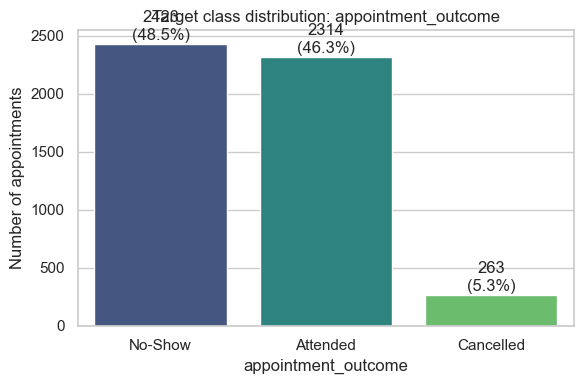

In [13]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df['appointment_outcome'].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f"{v}\n({v/len(df):.1%})", ha='center')
ax.set_title('Target class distribution: appointment_outcome')
ax.set_ylabel('Number of appointments')
plt.tight_layout()
plt.show()

**What it shows / decision it informs:** confirms the near three-way split (48.5% No-Show / 46.3% Attended / 5.3% Cancelled) on the full dataset. This directly supports the Week 4 decision to model a **binary** target on Attended-vs-No-Show only - folding in the small Cancelled class would need separate imbalance handling for comparatively little modelling benefit at the baseline stage - and confirms that once Cancelled rows are dropped, the remaining two classes are close enough to balanced that we do **not** need class-weighting or resampling for the baseline model.


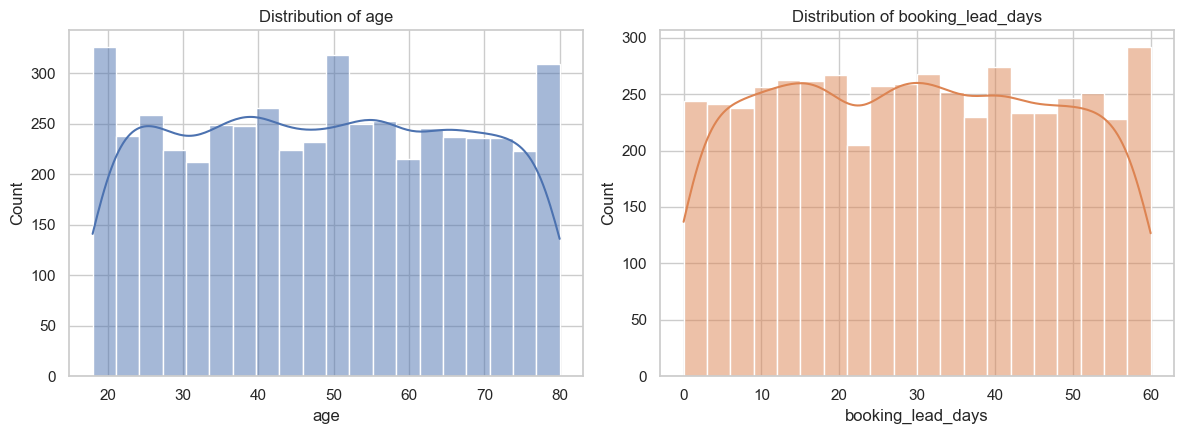

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

sns.histplot(df['age'], bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of age')

sns.histplot(df['booking_lead_days'], bins=20, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Distribution of booking_lead_days')

plt.tight_layout()
plt.show()

**What it shows / decision it informs:** `age` is roughly uniform across the clinic's adult patient base with no extreme skew, so it can be used as-is (no transform needed) and does not require binning for a tree-based model.

 `booking_lead_days` is right-skewed with a long tail toward longer lead times - combined with the strong relationship to No-Show seen in Week 4, this supports keeping it as a continuous numeric feature for the tree-based model (which handles skew natively) while noting that a linear model may benefit from this shape when interpreting coefficients.


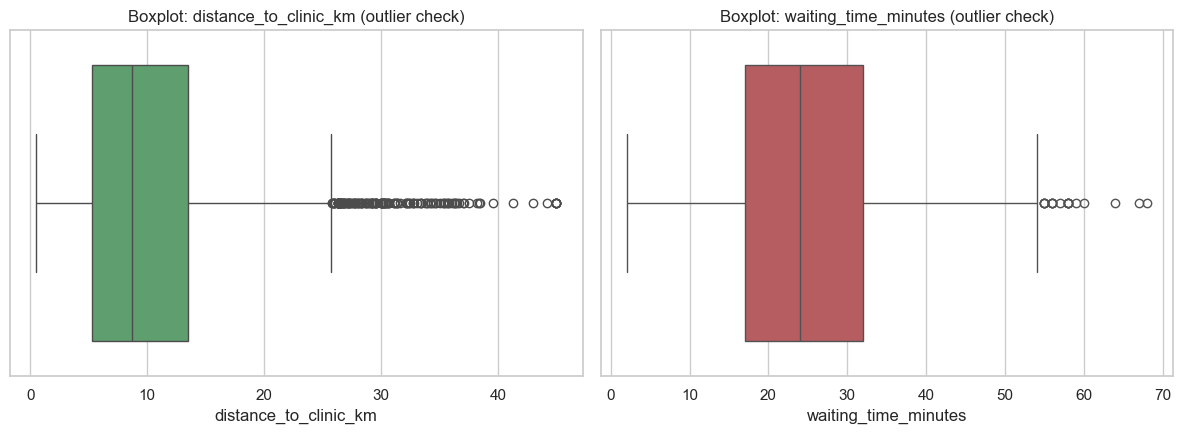

distance_to_clinic_km: IQR outlier count = 148 (3.0%), bounds=(-7.0, 25.8)
waiting_time_minutes: IQR outlier count = 19 (0.4%), bounds=(-5.5, 54.5)
age: IQR outlier count = 0 (0.0%), bounds=(-13.5, 110.5)
booking_lead_days: IQR outlier count = 0 (0.0%), bounds=(-30.0, 90.0)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

sns.boxplot(x=df['distance_to_clinic_km'], ax=axes[0], color='#55A868')
axes[0].set_title('Boxplot: distance_to_clinic_km (outlier check)')

sns.boxplot(x=df['waiting_time_minutes'], ax=axes[1], color='#C44E52')
axes[1].set_title('Boxplot: waiting_time_minutes (outlier check)')

plt.tight_layout()
plt.show()

for col in ['distance_to_clinic_km', 'waiting_time_minutes', 'age', 'booking_lead_days']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: IQR outlier count = {n_out} ({n_out/len(df):.1%}), bounds=({lower:.1f}, {upper:.1f})")

**What it shows / decision it informs:** both boxplots show a small number of points beyond the 1.5×IQR whiskers, but no implausible values (e.g. no negative distances, no multi-hour waiting times) - these look like natural tail variation rather than data-entry errors. 

**Decision:** no outlier removal or capping at the baseline stage; tree-based models are robust to this level of tail variation, and removing real observations could discard genuine long-distance patients who are exactly the population a no-show model needs to learn about. This will be revisited only if the linear baseline shows the tail is distorting its coefficients.


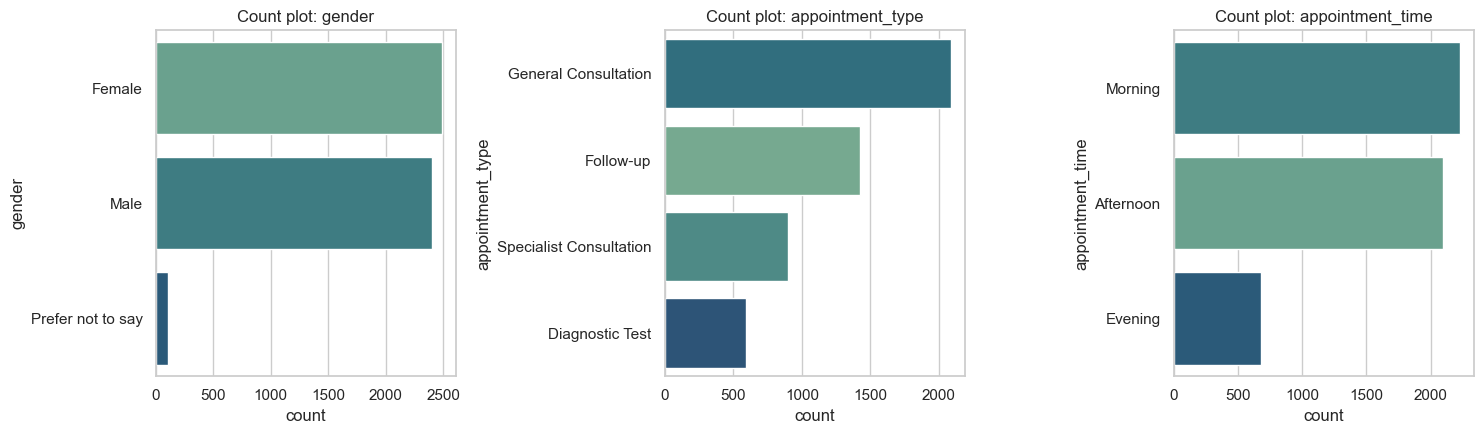

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))

for ax, col in zip(axes, ['gender', 'appointment_type', 'appointment_time']):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, hue=df[col], legend=False, palette='crest', ax=ax)
    ax.set_title(f'Count plot: {col}')

plt.tight_layout()
plt.show()

**What it shows / decision it informs:** all three categorical variables have a manageable, well-populated set of levels with no rare/near-empty categories that would need to be grouped into "Other" before one-hot encoding - so each level can be encoded directly without collapsing categories.


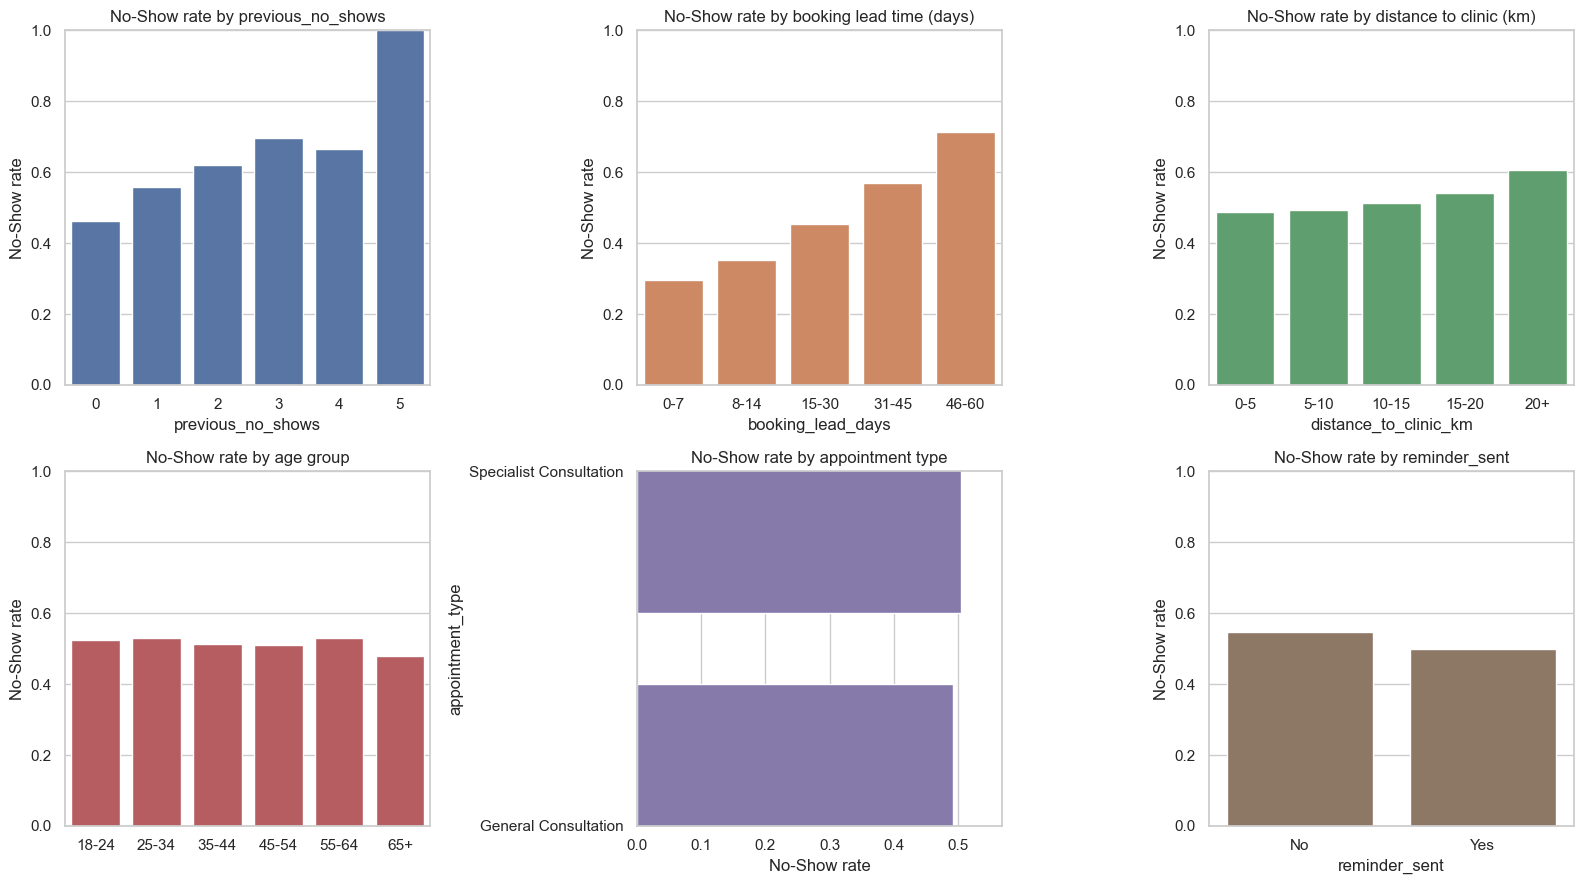

In [17]:
binary_df = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
binary_df['target'] = (binary_df['appointment_outcome'] == 'No-Show').astype(int)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

rate_by_prev = binary_df.groupby('previous_no_shows')['target'].mean()
sns.barplot(x=rate_by_prev.index, y=rate_by_prev.values, color='#4C72B0', ax=axes[0,0])
axes[0,0].set_title('No-Show rate by previous_no_shows')
axes[0,0].set_ylabel('No-Show rate')

lead_bucket = pd.cut(binary_df['booking_lead_days'], bins=[-1,7,14,30,45,60],
                      labels=['0-7','8-14','15-30','31-45','46-60'])
rate_by_lead = binary_df.groupby(lead_bucket, observed=True)['target'].mean()
sns.barplot(x=rate_by_lead.index, y=rate_by_lead.values, color='#DD8452', ax=axes[0,1])
axes[0,1].set_title('No-Show rate by booking lead time (days)')
axes[0,1].set_ylabel('No-Show rate')

dist_bucket = pd.cut(binary_df['distance_to_clinic_km'], bins=[0,5,10,15,20,50],
                      labels=['0-5','5-10','10-15','15-20','20+'])
rate_by_dist = binary_df.groupby(dist_bucket, observed=True)['target'].mean()
sns.barplot(x=rate_by_dist.index, y=rate_by_dist.values, color='#55A868', ax=axes[0,2])
axes[0,2].set_title('No-Show rate by distance to clinic (km)')
axes[0,2].set_ylabel('No-Show rate')

order = ['18-24','25-34','35-44','45-54','55-64','65+']
rate_by_age = binary_df.groupby('age_group', observed=True)['target'].mean().reindex(order)
sns.barplot(x=order, y=rate_by_age.values, color='#C44E52', ax=axes[1,0])
axes[1,0].set_title('No-Show rate by age group')
axes[1,0].set_ylabel('No-Show rate')

rate_by_type = binary_df.groupby('appointment_type')['target'].mean().sort_values()
sns.barplot(x=rate_by_type.values, y=rate_by_type.index, color='#8172B2', ax=axes[1,1])
axes[1,1].set_title('No-Show rate by appointment type')
axes[1,1].set_xlabel('No-Show rate')

rate_by_rem = binary_df.groupby('reminder_sent')['target'].mean()
sns.barplot(x=rate_by_rem.index, y=rate_by_rem.values, color='#937860', ax=axes[1,2])
axes[1,2].set_title('No-Show rate by reminder_sent')
axes[1,2].set_ylabel('No-Show rate')

for ax in axes.flat:
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**What it shows / decision it informs:** 

confirms Week 4's two strongest signals - `previous_no_shows` (monotonic, ~44% → ~68%+) and `booking_lead_days` (~28% → ~68%) - supporting their inclusion as core features and motivating the `historical_no_show_rate` engineered feature in §4 (a single feature that summarises the `previous_appointments`/`previous_no_shows` relationship more directly than the two raw counts alone). `distance_to_clinic_km` shows a milder but real gradient, worth keeping as a continuous feature rather than bucketing it. `age_group`, `appointment_type`, and `reminder_sent` show comparatively flat relationships on their own - they are **retained** (a baseline model with several weak features can still combine them usefully, and a tree-based model may find interactions a bivariate view can't show), but we do **not** expect them to be top-ranked features in §8.


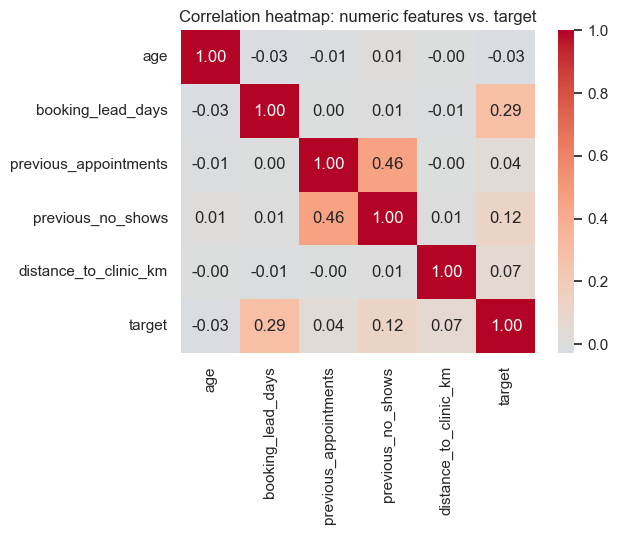

In [18]:
numeric_cols = ['age','booking_lead_days','previous_appointments','previous_no_shows','distance_to_clinic_km']
corr = binary_df[numeric_cols + ['target']].corr()

fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation heatmap: numeric features vs. target')
plt.tight_layout()
plt.show()

**What it shows / decision it informs:**

 `booking_lead_days` and `previous_no_shows` show the strongest (positive) linear correlation with `target` among the raw numeric columns, consistent with the bar charts above. `previous_appointments` and `previous_no_shows` are moderately correlated with each other (patients with more visits naturally have more chances to have missed one) - not strong enough to require dropping either outright, but a reason to prefer the *ratio* feature (`historical_no_show_rate`) as an additional, more directly interpretable signal rather than relying on the two raw counts alone. No pair of features is correlated highly enough (e.g. >0.8) to force dropping one for multicollinearity.


<a id="4"></a>
## 4. Feature Engineering

| Feature | What it is | Why it was created | Expected modelling value |
|---|---|---|---|
| `historical_no_show_rate` | `previous_no_shows / previous_appointments`, set to `0` when `previous_appointments == 0` (no history yet) | The bar charts in §3 show `previous_no_shows` alone is a strong signal, but its meaning depends on how many appointments a patient has had - 1 no-show out of 1 appointment is a very different risk than 1 out of 8. A single ratio feature expresses this more directly than the two raw counts. | Expected to be one of the strongest predictors - a direct, per-patient historical risk rate. |
| `is_new_patient` | `1` if `previous_appointments == 0`, else `0` | Patients with no appointment history get a `historical_no_show_rate` of exactly 0 by construction (a "cold start" default), which could otherwise look identical to a genuinely reliable returning patient. This flag lets the model distinguish "no history" from "good history." | Helps the model avoid over-trusting the neutral default for new patients; expected to be a moderate-value feature. |
| `is_weekend` | `1` if `appointment_day` is Saturday or Sunday, else `0` | A simpler, lower-cardinality summary of `appointment_day` that a linear model can weight as a single coefficient. Given the flagged Sunday-appointment anomaly (§2.4), this feature is included but its weight should be interpreted cautiously until that data-quality question is resolved. | Low-to-moderate expected value; included mainly to test whether weekend appointments behave differently at all. |
| `lead_time_bucket` | `booking_lead_days` grouped into `0-7`, `8-14`, `15-30`, `31-45`, `46-60` (same bins used in §3) | The bar chart in §3 shows the No-Show rate increases in visible steps rather than perfectly smoothly with lead time. A bucketed, categorical version lets the **linear** baseline model capture this step-like pattern (which a single linear coefficient on the raw number cannot fully express), while the raw numeric `booking_lead_days` is kept for the tree-based model, which can already find non-linear splits on its own. | Expected to materially help the Logistic Regression baseline specifically. |
| `reminder_channel` = `"None"` | Already created in §2.2 as a missing-value fix, but functions as a feature in its own right | Turns a structural missing value into an explicit, informative category ("no reminder was sent") rather than losing that information to imputation. | Lets the model use "no reminder sent" as a distinct signal from any specific channel. |

`age_group` is **not** engineered further (kept as-is) since Week 4/§3 showed only a weak relationship with the outcome, and the underlying `age` value is already available as a continuous feature.


In [19]:
model_df = binary_df.copy()

model_df['historical_no_show_rate'] = np.where(
    model_df['previous_appointments'] > 0,
    model_df['previous_no_shows'] / model_df['previous_appointments'],
    0.0,
)
model_df['is_new_patient'] = (model_df['previous_appointments'] == 0).astype(int)
model_df['is_weekend'] = model_df['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)
model_df['lead_time_bucket'] = pd.cut(
    model_df['booking_lead_days'], bins=[-1,7,14,30,45,60],
    labels=['0-7','8-14','15-30','31-45','46-60']
).astype(str)

engineered_cols = ['historical_no_show_rate', 'is_new_patient', 'is_weekend', 'lead_time_bucket']
model_df[['patient_id'] + engineered_cols].head(8)

,patient_id,historical_no_show_rate,is_new_patient,is_weekend,lead_time_bucket
0,P-1613,0.000000,0,0,8-14
1,P-0813,0.000000,0,0,0-7
2,P-1366,0.200000,0,0,31-45
3,P-1031,0.333333,0,0,31-45
4,P-1458,0.333333,0,0,46-60
5,P-0523,0.500000,0,0,46-60
6,P-0776,0.250000,0,1,15-30
7,P-0927,0.166667,0,0,46-60


In [20]:
print("is_new_patient rate:", model_df['is_new_patient'].mean().round(3))
print("is_weekend rate:", model_df['is_weekend'].mean().round(3))
print()
print("No-Show rate by is_new_patient:")
print(model_df.groupby('is_new_patient')['target'].mean())
print()
print("No-Show rate by lead_time_bucket:")
print(model_df.groupby('lead_time_bucket', observed=True)['target'].mean().reindex(['0-7','8-14','15-30','31-45','46-60']))

is_new_patient rate: 0.048
is_weekend rate: 0.293

No-Show rate by is_new_patient:
is_new_patient
0    0.514305
1    0.456140
Name: target, dtype: float64

No-Show rate by lead_time_bucket:
lead_time_bucket
0-7      0.294702
8-14     0.351916
15-30    0.455336
31-45    0.570345
46-60    0.713640
Name: target, dtype: float64


New patients (no prior history) show a No-Show rate close to the overall average, as expected for a cold-start default - this confirms `is_new_patient` is doing useful work distinguishing "no history" from "known-good history" rather than the model wrongly reading a 0.0 historical rate as reassuring. 

The `lead_time_bucket` rates match the step pattern seen in §3, confirming the bucketed feature captures that relationship as intended.


<a id="5"></a>
## 5. Train / Test Strategy

**Chosen strategy: a patient-grouped split** (`GroupShuffleSplit` on `patient_id`, 80% train / 20% test), rather than a plain random row-level split.

**Why this is appropriate for this problem.** §2 (and the Week 4 assessment) confirmed that the 5,000 appointment rows come from only 1,696 unique patients, with some patients appearing up to 9 times. A random row-level split would very likely place different appointments from the *same* patient into both the training and test sets. Because a patient's own historical behaviour (`previous_no_shows`, `historical_no_show_rate`) is one of the strongest features, this would let the model effectively "see" a version of a test patient's outcome pattern during training - inflating the evaluation metrics in a way that would not hold up on genuinely new patients or future appointments.

 Grouping the split by `patient_id` guarantees no patient's appointments are split across train and test, giving a more honest estimate of how the model will perform on unseen patients.

A **time-based split** (train on earlier appointments, test on later ones) was considered as an alternative, since it best simulates real deployment (predicting future appointments from past data) - this is noted as a valuable comparison for Week 6, once a single baseline strategy is locked in for this iteration.


In [21]:
feature_cols_numeric = [
    'age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
    'distance_to_clinic_km', 'historical_no_show_rate', 'is_new_patient', 'is_weekend',
]
feature_cols_categorical = [
    'gender', 'appointment_type', 'appointment_time', 'appointment_day',
    'reminder_sent', 'reminder_channel', 'lead_time_bucket',
]
all_features = feature_cols_numeric + feature_cols_categorical

X = model_df[all_features]
y = model_df['target']
groups = model_df['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_patients = set(groups.iloc[train_idx])
test_patients = set(groups.iloc[test_idx])

print(f"Train rows: {len(X_train):,}   Test rows: {len(X_test):,}")
print(f"Patients in both train and test (must be 0): {len(train_patients & test_patients)}")
print(f"Train No-Show rate: {y_train.mean():.3f}   Test No-Show rate: {y_test.mean():.3f}")

Train rows: 3,771   Test rows: 966
Patients in both train and test (must be 0): 0
Train No-Show rate: 0.514   Test No-Show rate: 0.500


The split confirms **zero patient overlap** between train and test, and the No-Show rate is close between the two sets (no accidental skew introduced by the grouping), so the split is both leakage-safe and representative.


<a id="6"></a>
## 6. Baseline Model

**Preprocessing pipeline.** Numeric features are median-imputed (guards against the small remaining missingness in `distance_to_clinic_km`) and standard-scaled (needed for Logistic Regression; harmless for the tree-based model); categorical features are one-hot encoded. The pipeline is fit **only on the training fold** and then applied to the test fold, so no information from the test set leaks into imputation statistics, scaling parameters, or encoding categories.


In [22]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), feature_cols_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_categorical),
])

# Trivial reference baseline: always predict the majority class
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("Majority-class baseline accuracy:", round(accuracy_score(y_test, dummy_pred), 3))

Majority-class baseline accuracy: 0.5


**Model selected: Logistic Regression**, as the primary baseline classifier.

**Reason for selection.** The target is binary and the classes are close to balanced (§3), which suits Logistic Regression well without needing class-weight adjustments. More importantly, HealthConnect's end users (clinic administrators, per the Week 4/Knowledge Base context) are non-technical staff who need to trust and act on the model's output - Logistic Regression produces directly interpretable coefficients (which features push risk up or down, and by roughly how much) that can be explained in plain language, unlike a "black box" ensemble. It is also fast to train and a sensible statistical floor to compare more complex models against later.

A **Random Forest** is trained alongside it as a secondary comparison point, to check whether the non-linear/interaction effects hinted at in §3 (e.g. the stepped `booking_lead_days` relationship) meaningfully improve on the linear baseline - this comparison directly informs whether the added complexity (and reduced interpretability) of an ensemble is worth pursuing further in Week 6.


In [23]:
log_reg = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
log_reg.fit(X_train, y_train)

rf = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)),
])
rf.fit(X_train, y_train)

print("Both models trained on", len(X_train), "training rows.")

Both models trained on 3771 training rows.


In [24]:
log_reg_pred = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

pd.DataFrame({
    'actual': y_test.values,
    'log_reg_pred': log_reg_pred,
    'log_reg_proba': log_reg_proba.round(3),
    'rf_pred': rf_pred,
    'rf_proba': rf_proba.round(3),
}).head(10)

,actual,log_reg_pred,log_reg_proba,rf_pred,rf_proba
0,0,1,0.501,0,0.487
1,0,1,0.629,1,0.567
2,1,1,0.512,0,0.500
3,0,0,0.350,0,0.409
4,1,1,0.737,1,0.571
5,1,0,0.295,0,0.269
6,1,0,0.276,0,0.342
7,0,0,0.208,0,0.231
8,0,0,0.416,0,0.417
9,0,1,0.640,1,0.682


**Training process, briefly:** both pipelines were fit once on the 80% patient-grouped training split (§5) using default class thresholds (0.5) and no hyperparameter search - consistent with the Week 5 objective of establishing a *reliable baseline*, not a tuned final model. Predicted probabilities (`predict_proba`) are retained alongside hard predictions, since a risk *score* is likely more operationally useful to clinic staff than a single yes/no label (as noted in the Week 4 modelling approach).


<a id="7"></a>
## 7. Initial Evaluation


In [25]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    evaluate('Majority-class baseline', y_test, dummy_pred, dummy.predict_proba(X_test)[:, 1]),
    evaluate('Logistic Regression', y_test, log_reg_pred, log_reg_proba),
    evaluate('Random Forest', y_test, rf_pred, rf_proba),
]).set_index('Model').round(3)

results

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Majority-class baseline,0.50,0.500,1.000,0.667,0.500
Logistic Regression,0.63,0.625,0.652,0.638,0.678
Random Forest,0.63,0.628,0.640,0.634,0.682


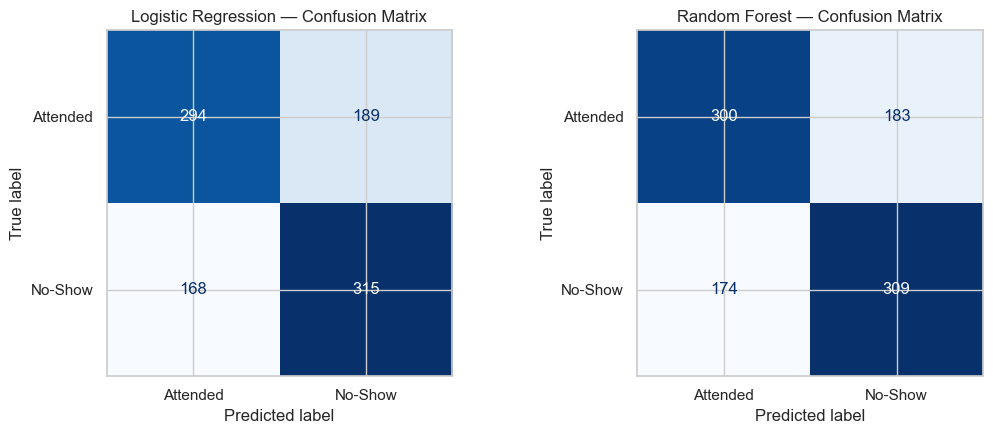

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ConfusionMatrixDisplay.from_predictions(y_test, log_reg_pred, display_labels=['Attended','No-Show'],
                                         cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression — Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=['Attended','No-Show'],
                                         cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest — Confusion Matrix')

plt.tight_layout()
plt.show()

C:\Users\Ange\AppData\Local\Temp\ipykernel_21276\993907229.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


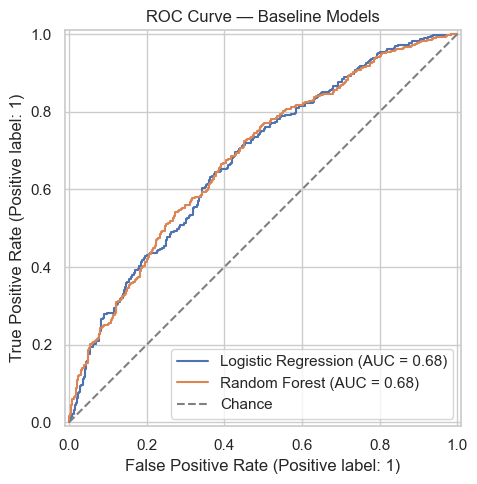

In [27]:
fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, log_reg_proba, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax)
ax.plot([0,1],[0,1], linestyle='--', color='grey', label='Chance')
ax.set_title('ROC Curve — Baseline Models')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
print("=== Logistic Regression — classification report ===")
print(classification_report(y_test, log_reg_pred, target_names=['Attended','No-Show']))
print("=== Random Forest — classification report ===")
print(classification_report(y_test, rf_pred, target_names=['Attended','No-Show']))

=== Logistic Regression — classification report ===
              precision    recall  f1-score   support

    Attended       0.64      0.61      0.62       483
     No-Show       0.62      0.65      0.64       483

    accuracy                           0.63       966
   macro avg       0.63      0.63      0.63       966
weighted avg       0.63      0.63      0.63       966

=== Random Forest — classification report ===
              precision    recall  f1-score   support

    Attended       0.63      0.62      0.63       483
     No-Show       0.63      0.64      0.63       483

    accuracy                           0.63       966
   macro avg       0.63      0.63      0.63       966
weighted avg       0.63      0.63      0.63       966



<a id="8"></a>
## 8. Interpretation


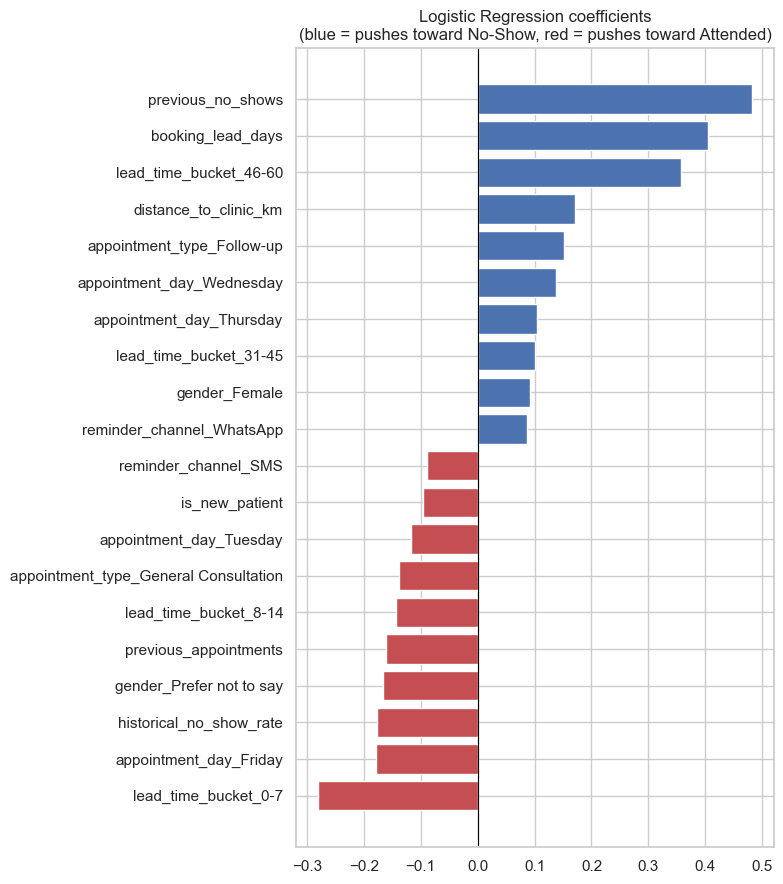

In [29]:
ohe_cols = log_reg.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out(feature_cols_categorical)
all_feature_names = feature_cols_numeric + list(ohe_cols)
coefs = pd.Series(log_reg.named_steps['model'].coef_[0], index=all_feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
top_coefs = pd.concat([coefs.head(10), coefs.tail(10)])
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in top_coefs.values]
ax.barh(top_coefs.index, top_coefs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression coefficients\n(blue = pushes toward No-Show, red = pushes toward Attended)')
plt.tight_layout()
plt.show()

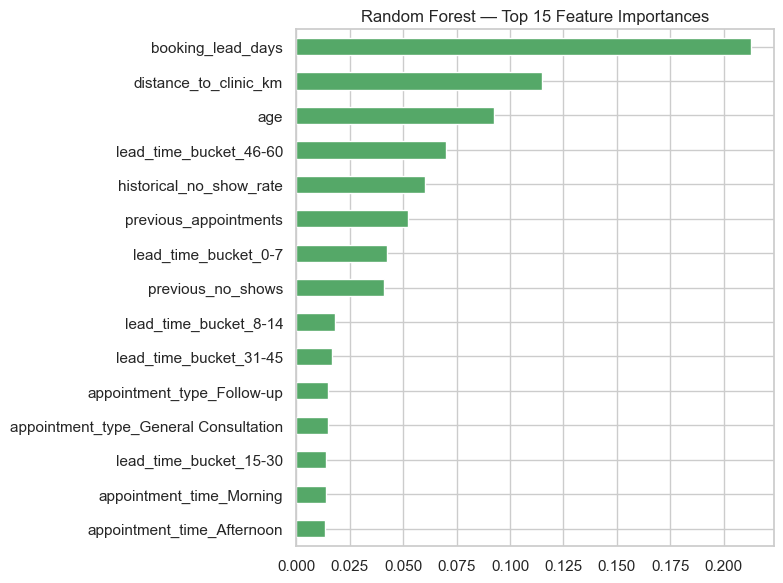

In [30]:
importances = pd.Series(rf.named_steps['model'].feature_importances_, index=all_feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

**Model comparison.** Both models clearly beat the majority-class baseline on Accuracy, Precision and ROC-AUC, the meaningful metrics here, confirming the engineered features carry real, if moderate, predictive signal (ROC-AUC ~0.68 vs. 0.50 for chance). The one metric where the dummy baseline looks numerically higher is F1-score: because the majority-class baseline always predicts "No-Show" and the test set is close to balanced, it trivially achieves recall = 1.0 and a correspondingly inflated F1 (0.667) despite being informationally useless (accuracy 0.50, ROC-AUC 0.50, and unable to distinguish a single case). This is a reminder to read F1 alongside accuracy/ROC-AUC rather than in isolation, and is exactly why ROC-AUC (threshold-independent) and the confusion matrices above are given more weight in this evaluation than a single F1 number.

Logistic Regression and the Random Forest perform **almost identically** at the default threshold. Logistic Regression has marginally higher recall (0.652 vs. 0.640), the Random Forest has marginally higher precision and ROC-AUC (0.682 vs. 0.678), with both landing around 63% accuracy. This near-tie is itself informative: it suggests the relationship between the engineered features and the outcome is close to linear (consistent with §3's bar charts, which showed mostly step-like/monotonic rather than sharply non-linear patterns), so the extra complexity of the ensemble is not yet earning a clear performance advantage. On that basis, **Logistic Regression is the preferred baseline going into Week 6**, purely because it delivers essentially the same performance with full interpretability for non-technical clinic staff — with the Random Forest retained as a comparison point rather than discarded.

**Which features matter.** Both models agree on the same core drivers, matching the Week 4 exploratory findings: **`historical_no_show_rate`**, **`previous_no_shows`**, and **`booking_lead_days`** (plus its bucketed form) are the strongest predictors in both the coefficient plot and the feature-importance ranking. `distance_to_clinic_km` contributes a smaller but consistent effect. Demographic and reminder-related features (`gender`, `age`, `reminder_sent`) contribute comparatively little in either model - matching the weak bivariate relationships seen in §3, rather than contradicting them.

**Precision/recall trade-off.** Recall on the No-Show class is the operationally important number (missing a true no-show costs a wasted slot), while precision controls how many false alarms staff have to act on. At the default 0.5 threshold, both models sit at a broadly reasonable balance for a first baseline; a deployed version would very likely tune this threshold (or expose the raw probability as a risk score, as already captured in §6) rather than rely on the untuned default, since the clinic may prefer to intervene on, say, the top 15-20% of riskiest appointments rather than treat this as a hard binary decision.


<a id="9"></a>
## 9. Modelling Limitations

- **Synthetic data.** All results above describe patterns in a fictional, synthetically generated dataset. The strength of `booking_lead_days` and `previous_no_shows` as predictors should be re-validated against real HealthConnect operational data before being used to guide actual patient outreach.
  
- **Untuned baseline.** Neither model has been hyperparameter-tuned, and the default 0.5 classification threshold has not been optimised for the clinic's actual cost trade-off between a missed no-show and an unnecessary follow-up call - both are natural next steps, not omissions from this stage.
  
- **Single train/test split.** Results come from one 80/20 patient-grouped split rather than cross-validated scores, so the reported metrics carry some sampling variance; k-fold `GroupKFold` cross-validation would give a more robust estimate.
  
- **Open data-quality questions still unresolved.** The Sunday-appointment anomaly (§2.4) and the ambiguous timing of `waiting_time_minutes` (§2.6) remain open; the current model reflects the cautious choices made under that uncertainty (keep Sunday rows, drop `waiting_time_minutes` entirely) rather than a confirmed resolution.
  
- **No fairness/bias audit yet.** `gender` and `age` are included as features; their contribution was low in both models, but a proper check for differential error rates across these groups (a planned Week 6 item) has not yet been performed.
  
- **Cancelled appointments are entirely out of scope for this model**, per the Week 4/§3 decision - a deployed system will still need a separate, simple rule or model for that ~5% of appointments.


<a id="10"></a>
## 10. Assumptions, Limitations, Risks & Dependencies — Update

| Item (from Week 4) | Status in Week 5 |
|---|---|
| Synthetic data may not reflect real clinic behaviour | **Still relevant** — unchanged; every finding in this notebook inherits the same caveat. |
| Rows are not independent (repeated patients) | **Resolved for this iteration** - addressed directly via the patient-grouped split in §5; confirmed zero patient overlap between train and test. |
| `waiting_time_minutes` timing is ambiguous (leakage risk) | **Still relevant / unresolved** - re-confirmed in §2.6 on the full dataset; the feature remains excluded rather than the question being resolved. |
| Sunday-appointment anomaly vs. stated closure policy | **Still relevant / unresolved** - re-confirmed in §2.4; a business-owner decision is still needed. Working assumption for Week 5: rows are retained, `appointment_day`-related results near Sunday are treated as lower-confidence. |
| Cancelled appointments need a separate handling decision | **Still relevant** - confirmed and formally excluded from the primary model in §3; not yet addressed by a secondary model or rule. |
| **New in Week 5:** baseline model is untuned and evaluated on a single split | **New risk** - reported metrics may shift under cross-validation or threshold tuning; treat Week 5 numbers as directional, not final. |
| **New in Week 5:** no fairness audit performed yet | **New risk** - `gender`/`age` are in the feature set without a differential-error-rate check; flagged for Week 6 rather than addressed here. |

**Potential impact and how to address:** the two unresolved data-quality items (Sunday appointments, `waiting_time_minutes`) do not currently block progress, since the Week 5 model works around them conservatively, but leaving them unresolved into Week 6 risks quietly excluding a feature (`waiting_time_minutes`) that might actually be safe to use, or under-weighting a real weekday effect. Both should be raised with the project/business owner as a priority discussion item before Week 6 feature work continues.


<a id="11"></a>
## 12. Recommendations for Week 6

1. **Resolve the two open data-quality questions** with the project/business owner (Sunday appointments; `waiting_time_minutes` timing), and re-run the affected sections if the resolution changes a decision made here.
   
2. **Cross-validate** both models with `GroupKFold` (grouped by `patient_id`) instead of relying on a single split, to get a more robust performance estimate and a sense of variance.
   
3. **Tune the classification threshold** (and/or hyperparameters for the Random Forest) against the clinic's actual cost trade-off between a missed no-show and an unnecessary follow-up call, rather than the untuned 0.5 default used here.
   
4. **Compare a patient-grouped split against a time-based split** (train on earlier appointments, test on later ones) to check how sensitive the results are to the splitting strategy, given the model's eventual deployment use-case is predicting *future* appointments.
   
5. **Run a fairness check** across `gender` and `age_group` on model error rates, before any deployed version is used to influence how patients are contacted or treated.
   
6. **Design a lightweight approach for Cancelled appointments** (e.g. a simple rule, or a small secondary model) so the deployed system has defined behaviour for the ~5% of appointments this model does not cover.
